In [ ]:
import jax
import jax.numpy as jnp

def sample_actions(act_logits, random_key, task, batch_size=1):
    """
    act_logits:
       For "sampling": shape (parallel_env, 1, 2*action_dim)
       For "batch": same input shape; output will have an extra sample axis.
    random_key: jax PRNG key
    task: "sampling" or "batch"
    batch_size: number of samples per env (only used in "batch" branch)
    """
    if task == "batch":
        batch_size = 1  # number of samples per env
        action_dim = act_logits.shape[-1] // 2

        act_logits  = act_logits = jnp.repeat(act_logits, batch_size, axis=2)
        means = act_logits[..., :action_dim]
        log_stds = act_logits[..., action_dim:]
        log_stds = jnp.clip(log_stds, -20.0, 2.0)
        stds = jnp.exp(log_stds)
        # print("my ass", log_stds, means)
        # 4. Sample noise and compute actions:
        noise = jax.random.normal(random_key, shape=means.shape)  # shape: (parallel_env, batch_size, action_dim)
        # print("n", noise.shape, noise)
        acts_tick = means + noise * stds  # shape: (parallel_env, batch_size, action_dim)

    elif task == "sampling":
        action_dim = act_logits.shape[-1] // 2
        means = act_logits[..., :action_dim].squeeze(-1)
        log_stds = act_logits[..., action_dim:].squeeze(-1)
        # print("policy_out", act_logits.shape, "mean", means.shape, "std", log_stds.shape)
        
        # Clip log_stds for numerical stability
        log_stds = jnp.clip(log_stds, -20.0, 2.0)
        stds = jnp.exp(log_stds)
        # print("my pus", log_stds, means)
        # Sample from standard normal and scale
        noise = jax.random.normal(random_key, means.shape)
        # print("f", noise.shape, noise)
        acts_tick = means + noise * stds
        # print(acts_tick.shape)
        # jax.debug.print("dit kan echt niet meer {} {} {} ", means.shape, log_stds.shape, acts_tick.shape)
        acts_tick = jnp.squeeze(acts_tick)
        

    else:
        raise ValueError("Invalid task. Choose either 'batch' or 'sampling'.")
    return acts_tick

def gaussian_log_prob(actions, act_logits, task):
    print(act_logits.shape, actions.shape)
    """
    actions:
       For "sampling": shape (time, env_steps, action_dim)  (e.g., (1, 256, 1))
       For "batch": if actions lack a sample axis, one will be added.
    act_logits:
       For "sampling": shape (time, env_steps, 1, 2*action_dim)
       For "batch": same expected shape.
    Returns:
       Gaussian log-probabilities. For "batch" mode, the log-probabilities are computed per sample
       (optionally summed over the action dimension).
    """
    if task == "sampling":
        action_dim = act_logits.shape[-1] // 2
        means = act_logits[..., :action_dim].squeeze()
        log_stds = act_logits[..., action_dim:].squeeze()
        
        
        # Clip log_stds for numerical stability
        log_stds = jnp.clip(log_stds, -20.0, 2.0)
        
        
        variance = jnp.exp(2 * log_stds)
        # print("variance", variance, "means", means, "log_stds", log_stds)
        
        log_prob = -0.5 * (
            jnp.log(2 * jnp.pi)
            + 2 * log_stds
            + (actions - means) ** 2 / variance
                    )

    elif task == "batch":
        action_dim = act_logits.shape[-1] // 2
        batch_size = 1
        act_logits = jnp.broadcast_to(act_logits, (act_logits.shape[0], act_logits.shape[1], batch_size, act_logits.shape[2]))
        act_logits = jnp.repeat(act_logits, batch_size, axis=2)
        means = act_logits[..., :action_dim]
        log_stds = act_logits[..., action_dim:]
        
        
    
        log_stds = jnp.clip(log_stds, -20.0, 2.0)
        variance = jnp.exp(2 * log_stds)
        # print("variance", variance, "means", means, "log_stds", log_stds)
        
        log_prob = -0.5 * (jnp.log(2 * jnp.pi) + 2 * log_stds + ((actions - means) ** 2) / variance)
        log_prob = jnp.squeeze(log_prob.sum(axis=2), axis=-1)

    else:
        raise ValueError("Invalid task. Choose either 'batch' or 'sampling'.")
    return log_prob




In [86]:
# -------------------------------
# Testing the functionality

key = jax.random.PRNGKey(0)

# print("=== Testing sample_actions ===")
# # For "sampling" branch:
# # Input: (parallel_env, 1, 2*action_dim) e.g. (8, 1, 2) with action_dim=1.
# # act_logits_sampling = jax.random.normal(key, shape=(8, 1, 2))
# act_logits_sampling = jax.numpy.ones((8, 1, 2))
# print("act_logits_sampling", act_logits_sampling.shape)
# # key, subkey = jax.random.split(key)
# sampled_sampling = sample_actions(act_logits_sampling, key, task="sampling")
# # print("Sampling branch output (should be shape (8,) or (8,1) after squeezing):", sampled_sampling.shape)
# # print("Sampling branch output:", sampled_sampling)

# # For "batch" branch with batch_size = 1:
# # key, subkey = jax.random.split(key)
# sampled_batch = sample_actions(act_logits_sampling, key, task="batch", batch_size=1)
# # Remove singleton sample dimension for comparison:
# # sampled_batch_squeezed = jnp.squeeze(sampled_batch)
# # print("Batch branch (batch_size=1) output (after squeezing, should be same as sampling):", sampled_batch_squeezed.shape)
# # print("Batch branch output:", sampled_batch_squeezed)
# print(sampled_sampling, "\n", sampled_batch)

print("\n=== Testing gaussian_log_prob ===")
# For "sampling" branch log_prob:
# Let act_logits have shape (time, env_steps, 1, 2*action_dim), e.g. (1, 256, 1, 2)
# And actions shape (1, env_steps, 1), e.g. (1, 256, 1)
env_steps = 8
# act_logits_log_prob = jax.random.normal(key, shape=(1, env_steps, 1, 2))
# actions_log_prob = jax.random.normal(key, shape=(1, env_steps))
act_logits_log_prob = jax.numpy.ones((1, env_steps, 2))
actions_log_prob = jax.numpy.ones((1, env_steps))
log_prob_sampling = gaussian_log_prob(actions_log_prob, act_logits_log_prob, task="sampling")
print("Gaussian log-prob (sampling) output shape:", log_prob_sampling)

# For "batch" branch log_prob:
act_logits_log_prob = jax.numpy.ones((1, env_steps, 1, 2))
actions_log_prob = jax.numpy.ones((1, env_steps, 1, 1))
act_logits_log_prob = jax.random.normal(key, shape=(1, env_steps, 1, 2))
actions_log_prob = jax.random.normal(key, shape=(1, env_steps, 1, 1))
log_prob_batch = gaussian_log_prob(actions_log_prob, act_logits_log_prob, task="batch")
print("Gaussian log-prob (batch) output shape:", log_prob_batch)

# Optionally, if you want to aggregate the samples (e.g., by summing over the sample axis),
# you could do:
# if log_prob_batch.ndim > 3:  # if sample axis exists
#     log_prob_batch_aggregated = log_prob_batch.sum(axis=2)
#     print("Gaussian log-prob (batch) aggregated over samples shape:", log_prob_batch_aggregated.shape)


=== Testing gaussian_log_prob ===
(1, 8, 2) (1, 8)
Gaussian log-prob (sampling) output shape: [[-1.9189385 -1.9189385 -1.9189385 -1.9189385 -1.9189385 -1.9189385
  -1.9189385 -1.9189385]]
(1, 8, 1, 2) (1, 8, 1, 1)
Gaussian log-prob (batch) output shape: [[  -2.9189386    -4.3780413    -1.2456048    -1.4456145    -0.76598185
  -246.85428      -1.3426186    -2.4443378 ]]


In [56]:
import jax.numpy as jnp
import numpy as np

# Example array of shape (1, 256, 1, 2)
array = np.random.rand(1, 2, 1, 2)  # Replace with your actual array
print(array)
# Desired expansion factor for the 3rd dimension (e.g., x = 4)
x = 4  

# Expand along the third axis
expanded_array = np.tile(array, (1, 1, x, 1))
a = np.repeat(array, x, axis=2)
print(a)
print(expanded_array.shape)  # Should output (1, 256, x, 2)

print(array,"\n", expanded_array)


[[[[0.7275847  0.898863  ]]

  [[0.26442263 0.96225166]]]]
[[[[0.7275847  0.898863  ]
   [0.7275847  0.898863  ]
   [0.7275847  0.898863  ]
   [0.7275847  0.898863  ]]

  [[0.26442263 0.96225166]
   [0.26442263 0.96225166]
   [0.26442263 0.96225166]
   [0.26442263 0.96225166]]]]
(1, 2, 4, 2)
[[[[0.7275847  0.898863  ]]

  [[0.26442263 0.96225166]]]] 
 [[[[0.7275847  0.898863  ]
   [0.7275847  0.898863  ]
   [0.7275847  0.898863  ]
   [0.7275847  0.898863  ]]

  [[0.26442263 0.96225166]
   [0.26442263 0.96225166]
   [0.26442263 0.96225166]
   [0.26442263 0.96225166]]]]


In [7]:
import numpy as np

class PolynomialFunction:
    def __init__(self, action_dim, degree, x_range):
        self.action_dim = action_dim
        self.degree = degree
        self.x_range = x_range
        self.shift_polynomial()

    def shift_polynomial(self):
        # Randomize the maximum location uniformly for each dimension.
        self.x_max = np.random.uniform(self.x_range[0], self.x_range[1], size=())
        # Randomize the constant such that f(x_max) = c, and weights.
        self.c = np.random.uniform(5.0, 20.0)
        self.weights = np.random.uniform(0.5, 2.0, size=(self.action_dim,))

    def compute_y(self, x):
        """
        Compute the polynomial value for a batch of inputs:
            f(x) = c - sum_{i=1}^{action_dim} (w_i * (x_i - x_max_i)**degree)
            
        Supports inputs of shape `(batch_size, action_dim)`.
        If `x` is `(action_dim,)`, it is treated as `(1, action_dim)`.
        """
        x = np.atleast_2d(x)  # Ensure x is (batch_size, action_dim)
        
        # Compute difference
        diff = x - self.x_max  # Shape: (batch_size, action_dim)
        print("x", x, " - ", self.x_max, " = ", diff)
        
        # Compute weighted polynomial term
        weighted_term = self.weights * (diff ** self.degree)  # Shape: (batch_size, action_dim)
        
        # Sum across action_dim to get final output
        result = self.c - np.sum(weighted_term, axis=1)  # Shape: (batch_size,)
        
        return result.squeeze()  # Convert (1,) to scalar if needed


poly_fn = PolynomialFunction(action_dim=3, degree=2, x_range=(-5, 5))

x_single = np.array([1.0, 2.0, 3.0])
y_single = poly_fn.compute_y(x_single)
print("Single input y:", y_single)

x_batch = np.array([[1.0, 2.0, 3.0], [0.5, 1.5, 2.5], [1.0, 2.0, 3.0]])
y_batch = poly_fn.compute_y(x_batch)
print("Batch input y:", y_batch)

x [[1. 2. 3.]]  -  -2.2850726594570894  =  [[3.28507266 4.28507266 5.28507266]]
Single input y: -72.21117464033254
x [[1.  2.  3. ]
 [0.5 1.5 2.5]
 [1.  2.  3. ]]  -  -2.2850726594570894  =  [[3.28507266 4.28507266 5.28507266]
 [2.78507266 3.78507266 4.78507266]
 [3.28507266 4.28507266 5.28507266]]
Batch input y: [-72.21117464 -54.51128128 -72.21117464]


In [1]:
import jax
import jaxlib

print("JAX version:", jax.__version__)
print("JAXLIB version:", jaxlib.__version__)


JAX version: 0.5.0
JAXLIB version: 0.5.0


In [ ]:
import jax
import jax.numpy as jnp
export CUDA_VISIBLE_DEVICES=0

print("JAX Devices:", jax.devices())

x = jnp.ones((1000, 1000))
print("Device for computation:", x.device())

JAX Devices: [CpuDevice(id=0)]


TypeError: 'Device' object is not callable

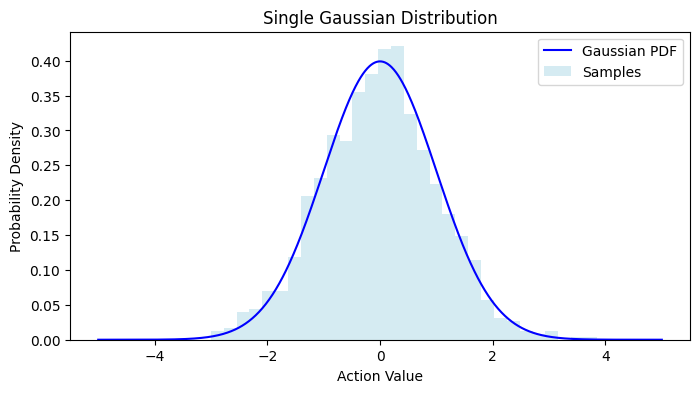

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters for the Gaussian
mu = 0.0
sigma = 1.0

# Domain for plotting the PDF
x = np.linspace(-5, 5, 1000)
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, 'b-', label='Gaussian PDF')
# Sample points from the Gaussian
samples = np.random.normal(mu, sigma, size=1000)
plt.hist(samples, bins=30, density=True, alpha=0.5, color='lightblue', label='Samples')
plt.title('Single Gaussian Distribution')
plt.xlabel('Action Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


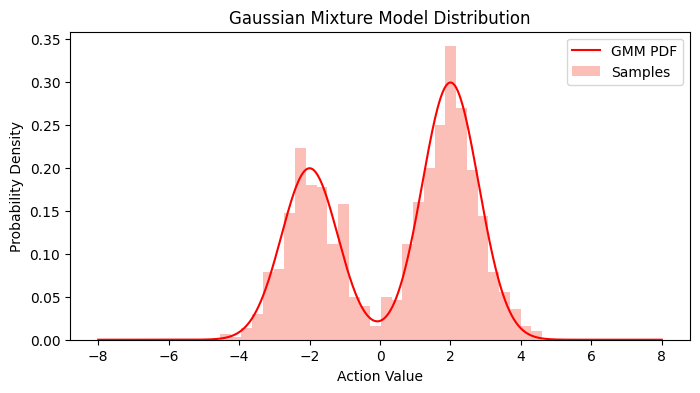

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters for two components
mu1, sigma1, w1 = -2, 0.8, 0.4
mu2, sigma2, w2 =  2, 0.8, 0.6

# Domain for plotting the PDF
x = np.linspace(-8, 8, 1000)
pdf = w1 * norm.pdf(x, loc=mu1, scale=sigma1) + w2 * norm.pdf(x, loc=mu2, scale=sigma2)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, 'r-', label='GMM PDF')

# Sample points from the GMM:
samples = []
for _ in range(1000):
    if np.random.rand() < w1:
        samples.append(np.random.normal(mu1, sigma1))
    else:
        samples.append(np.random.normal(mu2, sigma2))

plt.hist(samples, bins=30, density=True, alpha=0.5, color='salmon', label='Samples')
plt.title('Gaussian Mixture Model Distribution')
plt.xlabel('Action Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


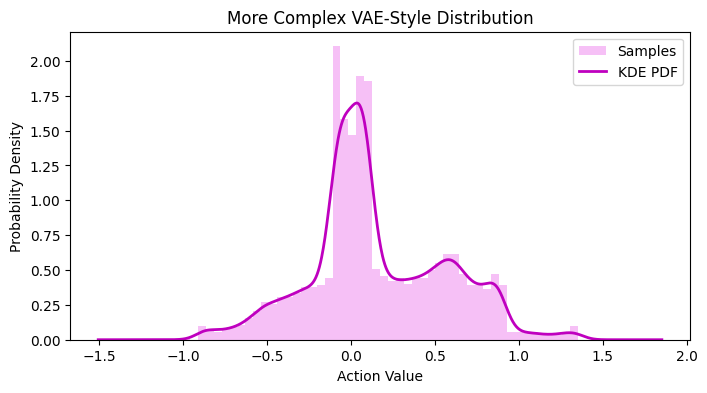

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1) Define a mixture distribution for the latent variable z
#    This mixture has two components, each a Gaussian.
def sample_z(n):
    z_samples = []
    p = 0.4  # mixing weight for the first component
    for _ in range(n):
        if np.random.rand() < p:
            # Sample from N(-2, 0.5^2)
            z_samples.append(np.random.normal(-2.0, 0.5))
        else:
            # Sample from N(2, 1.0^2)
            z_samples.append(np.random.normal(2.0, 1.0))
    return np.array(z_samples)

# 2) Define a more complex decoder function
#    Feel free to adjust this to get different shapes.
def decoder(z):
    # Non-linear combination of sin, cos, polynomials, etc.
    return 0.5 * np.sin(2.0 * z) + 0.3 * np.sin(3.0 * z) + 0.2 * z

# 3) Sample from the "VAE" by:
#    - drawing latent z from a mixture
#    - mapping z -> action a via the decoder
num_samples = 20000
z_samples = sample_z(num_samples)
a_samples = decoder(z_samples)

# 4) Use kernel density estimation (KDE) to approximate the PDF of a
density = gaussian_kde(a_samples, bw_method='scott')  
#   - "bw_method" controls the bandwidth. 'scott' or 'silverman' often work well.

# 5) Create a grid for plotting the PDF
xmin, xmax = min(a_samples), max(a_samples)
xrange = np.linspace(xmin - 0.5, xmax + 0.5, 1000)
pdf_est = density(xrange)

# 6) Plot histogram + estimated PDF
plt.figure(figsize=(8, 4))
plt.hist(a_samples, bins=50, density=True, alpha=0.5, color='violet', label='Samples')
plt.plot(xrange, pdf_est, 'm-', linewidth=2, label='KDE PDF')
plt.title('More Complex VAE-Style Distribution')
plt.xlabel('Action Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


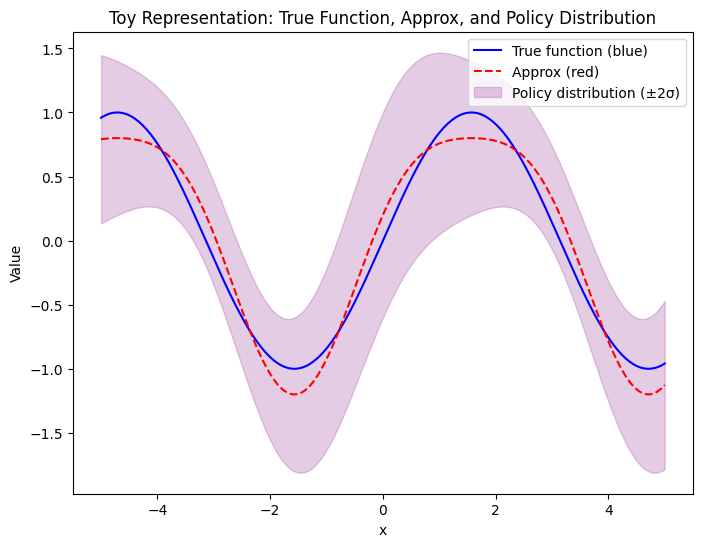

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1) "True" function (just for illustration)
def f_true(x):
    return np.sin(x)

# 2) "Nonlinear approximation" (like your LSTM-based net output)
def f_approx(x):
    return np.sin(x) + 0.2*np.cos(2*x)

# 3) A toy standard deviation function for the policy distribution
#    In reality, your policy net might output a log-variance or mixture weights, etc.
def policy_std(x):
    return 0.3 + 0.1*np.cos(x)

# Create a domain for x
x = np.linspace(-5, 5, 300)
y_true = f_true(x)
y_approx = f_approx(x)
std = policy_std(x)  # for the single-Gaussian policy

# Plot
plt.figure(figsize=(8, 6))

# (A) True function in blue
plt.plot(x, y_true, 'b-', label='True function (blue)')

# (B) Nonlinear approximation in red
plt.plot(x, y_approx, 'r--', label='Approx (red)')

# (C) Policy distribution in purple (±2 std around the approx)
plt.fill_between(x,
                 y_approx - 2*std,
                 y_approx + 2*std,
                 color='purple', alpha=0.2,
                 label='Policy distribution (±2σ)')

plt.title("Toy Representation: True Function, Approx, and Policy Distribution")
plt.xlabel("x")
plt.ylabel("Value")
plt.legend()
plt.show()


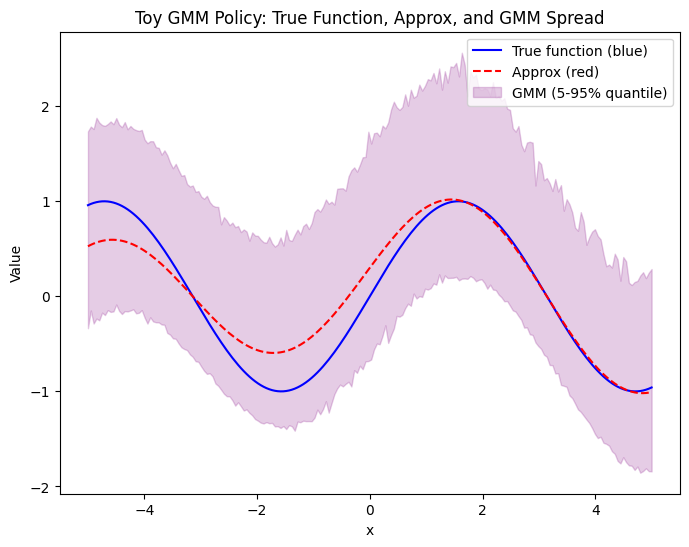

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Toy "true" function
def f_true(x):
    return np.sin(x)

# Toy "approx" function
def f_approx(x):
    return 0.8*np.sin(x) + 0.3*np.cos(0.5*x)

# For a GMM with 2 components at each x:
#   p(a | x) = w1(x)*N(mu1(x), std1(x)^2) + w2(x)*N(mu2(x), std2(x)^2)
# We'll define them just for illustration:
def gmm_params(x):
    # mixing weight
    w1 = 0.4 + 0.3*np.sin(0.2*x)
    w1 = (w1+1)/2  # shift to [0,1] range
    w2 = 1 - w1
    # means
    mu1 = f_approx(x) - 0.5
    mu2 = f_approx(x) + 1.0
    # std dev
    std1 = 0.2 + 0.1*np.cos(x)
    std2 = 0.3 + 0.15*np.sin(0.5*x)
    return w1, w2, mu1, mu2, std1, std2

# Let's do a quantile-based shading to show the "spread" of the GMM
def gmm_sample_quantiles(x, n_samples=200):
    # For each x, sample from the GMM many times, compute quantiles
    from numpy.random import randn, rand
    qs_5 = []
    qs_95 = []
    for xi in x:
        w1, w2, mu1, mu2, s1, s2 = gmm_params(xi)
        samples = []
        for _ in range(n_samples):
            if np.random.rand() < w1:
                samples.append(np.random.normal(mu1, s1))
            else:
                samples.append(np.random.normal(mu2, s2))
        samples = np.array(samples)
        qs_5.append(np.percentile(samples, 5))
        qs_95.append(np.percentile(samples, 95))
    return np.array(qs_5), np.array(qs_95)

# Main plotting
x = np.linspace(-5, 5, 200)
y_true = f_true(x)

qs_5, qs_95 = gmm_sample_quantiles(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_true, 'b-', label='True function (blue)')
plt.plot(x, f_approx(x), 'r--', label='Approx (red)')

# Purple shading from 5th to 95th percentile of the GMM
plt.fill_between(x, qs_5, qs_95, color='purple', alpha=0.2, label='GMM (5-95% quantile)')

plt.title("Toy GMM Policy: True Function, Approx, and GMM Spread")
plt.xlabel("x")
plt.ylabel("Value")
plt.legend()
plt.show()


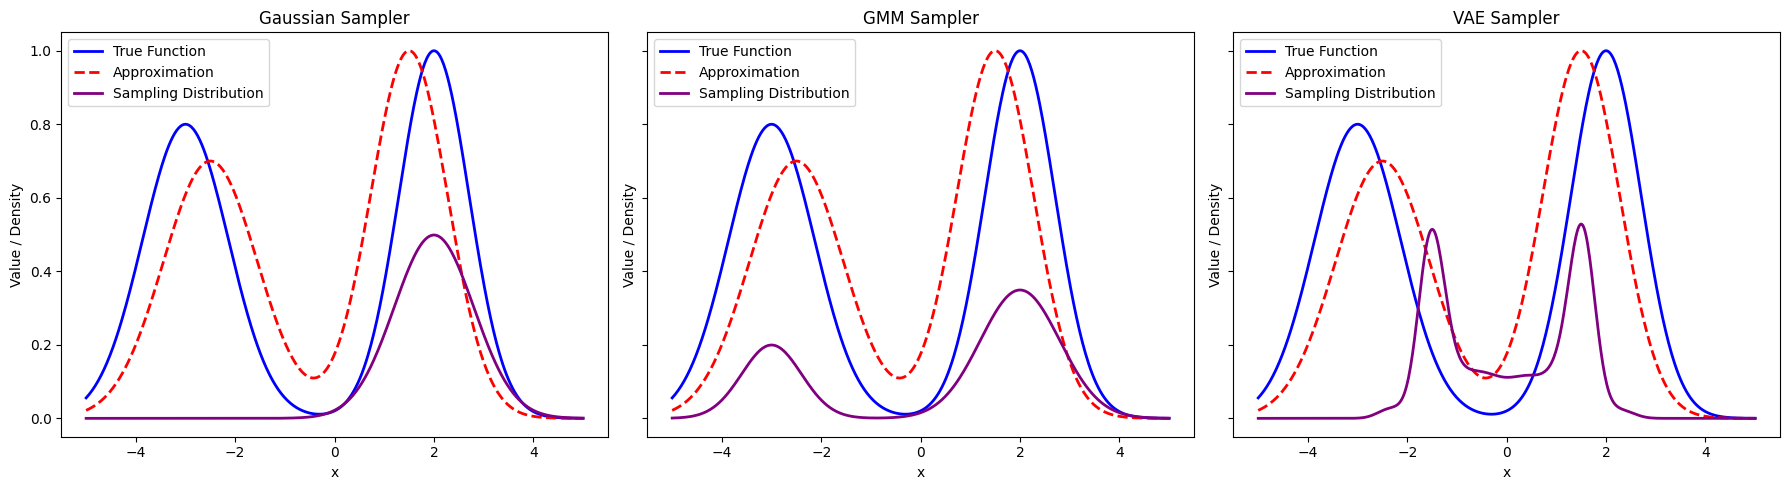

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# Define the domain (e.g., action space)
x = np.linspace(-5, 5, 500)

# --------------------------------------------------------------------
# 1. Define a "True" function (blue) with two peaks.
def f_true(x):
    # Two peaks: one strong peak near x=2, and a smaller one near x=-3.
    return np.exp(-((x-2)**2)/1.0) + 0.8*np.exp(-((x+3)**2)/1.5)

# 2. Define an approximation function (red)
def f_approx(x):
    # A slightly shifted and smoothed version of f_true.
    return np.exp(-((x-1.5)**2)/1.2) + 0.7*np.exp(-((x+2.5)**2)/1.8)

# --------------------------------------------------------------------
# 3a. Gaussian sampler: A unimodal Gaussian centered at the high peak.
# For illustration, we assume the policy produces a Gaussian
# around the best (highest) region of f_true.
gaussian_pdf = norm.pdf(x, loc=2, scale=0.8)
# Normalize over our domain:
gaussian_pdf = gaussian_pdf / np.trapz(gaussian_pdf, x)

# --------------------------------------------------------------------
# 3b. GMM sampler: A mixture of two Gaussians, one for each peak.
# Here we weight the peak near x=-3 less than the one near x=2.
gmm_pdf = 0.3 * norm.pdf(x, loc=-3, scale=0.6) + 0.7 * norm.pdf(x, loc=2, scale=0.8)
gmm_pdf = gmm_pdf / np.trapz(gmm_pdf, x)

# --------------------------------------------------------------------
# 3c. VAE sampler: A non-linear, non-Gaussian shaped distribution.
# We simulate this by transforming a latent variable z via a non-linear function.
def vae_transform(z):
    # A non-linear decoder mapping from latent space z to x.
    return 2 * np.tanh(z) + 0.5 * np.sin(3 * z)

# Sample latent variable z from a standard normal.
z_samples = np.random.randn(10000)
# Map z to x using the decoder.
x_samples_vae = vae_transform(z_samples)
# Estimate the resulting density via kernel density estimation.
kde = gaussian_kde(x_samples_vae)
vae_pdf = kde(x)
# Normalize the KDE (should be near 1, but we enforce it).
vae_pdf = vae_pdf / np.trapz(vae_pdf, x)

# --------------------------------------------------------------------
# Plotting: Create one row with three subplots (one per sampler)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = ['Gaussian Sampler', 'GMM Sampler', 'VAE Sampler']
sampler_pdfs = [gaussian_pdf, gmm_pdf, vae_pdf]

for ax, sampler_pdf, title in zip(axes, sampler_pdfs, titles):
    # Plot the "true" function (blue)
    ax.plot(x, f_true(x), 'b-', lw=2, label='True Function')
    # Plot the nonlinear approximation (red)
    ax.plot(x, f_approx(x), 'r--', lw=2, label='Approximation')
    # Plot the sampling distribution (purple)
    ax.plot(x, sampler_pdf, color='purple', lw=2, label='Sampling Distribution')
    
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('Value / Density')
    ax.legend()

plt.tight_layout()
plt.show()
